<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Project Introduction" data-toc-modified-id="Project Introduction-1">Project Introduction</a></span><ul class="toc-item"><li><span><a href="#Keywords" data-toc-modified-id="Keywords-1.1">Keywords</a></span></li></ul></li><li><span><a href="#Data Explorationanalysis" data-toc-modified-id="Data Explorationanalysis-2">Data Explorationanalysis</a></span></li><li><span><a href="#datafeatureextract" data-toc-modified-id="datafeatureextract-3">datafeatureextract</a></span></li><li><span><a href="#Support Vector Machine (SVM)Model Building" data-toc-modified-id="Support Vector Machine (SVM)Model Building-4">Support Vector Machine (SVM)Model Building</a></span></li><li><span><a href="#modelAssessment" data-toc-modified-id="modelAssessment-5">modelAssessment</a></span></li></ul></div>

## Project Introduction
Water QualityWater Color，through Water ColorWater Quality。
yesthrough Water ColorImageimplement Water QualityAssessment。
Water ColorWater Quality：
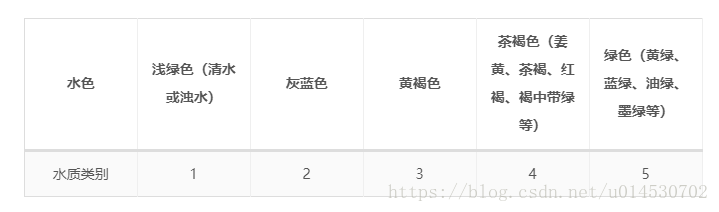

### Keywords
- featureextract、Support Vector Machine (SVM)、Confusion Matrix

## Data Explorationanalysis
- data

‘data/images’data，based onWater ColorWater QualityclassificationdataPerform dataanalysis。Water Quality“_.jpg”，1_1.jpgdescriptionsample。

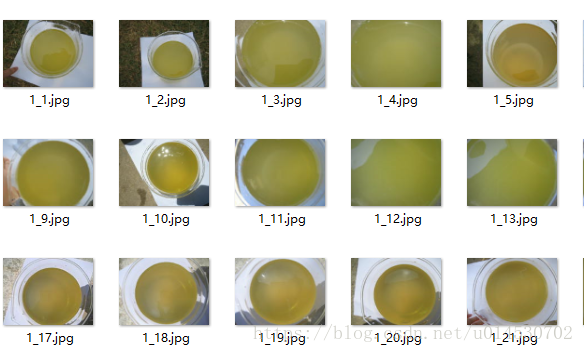

- 

based on，variableDistributionindicates and 。ImageDistributionyesDistribution，Image。ColorcontainsColor、 and ，AnalyzeRGBColorImage，R、G and BColor，9minute。		

Imageminute，using ColorextractImagefeature。

（1）Color

Colorusing ，Image。

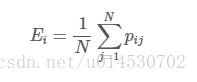

where ，EiyesiColorColor，AnalyzeRGBColorImage，i=1,2,3。where pijyesjiColorColor。

（2）Color

Colorusing yes，ImageColorDistribution。

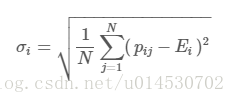

where σiyesiColorColor，EiyesiColorColor。

（3）Color

Colorusing yes，ImageColorDistributionAnalyze。

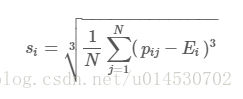

where ，siyesiColorColor，EiyesiColorColor。
AnalyzeImagefeatureextract，Water Quality and featuredata。

## datafeatureextract

ImageColorfeatureextract，Perform data，[0,1]。AnalyzeImageusing pillow。
Analyzedatafeatureextract，Analyzeresult，usingmodel，classificationEffectiveness。

Color。

In [50]:
import numpy as np
import pandas as pd
from sklearn import preprocessing
from PIL import Image
import os

def PicManage(path,i):
    pic = Image.open(path)
    pic.c_x, pic.c_y = (int(i/2) for i in pic.size)
    box = (pic.c_x-50, pic.c_y-50, pic.c_x+50, pic.c_y+50)
    #extract100*100
    region = pic.crop(box)
    
    #minuteRGB
    r, g, b = np.split(np.array(region), 3, axis = 2)
    
    #calculate
    r_m1 = np.mean(r)
    g_m1 = np.mean(g)
    b_m1 = np.mean(b)
    
    #
    r_m2 = np.std(r)
    g_m2 = np.std(g)
    b_m2 = np.std(b)
    
    #
    r_m3 = np.mean(abs(r - r.mean())**3)**(1/3)
    g_m3 = np.mean(abs(g - g.mean())**3)**(1/3)
    b_m3 = np.mean(abs(b - b.mean())**3)**(1/3)
    
    #data，[-1,1]
    typ = np.array([i])
    arr = np.array([r_m1,g_m1,b_m1,r_m2,g_m2,b_m2,r_m3,g_m3,b_m3])
    #df = pd.DataFrame(preprocessing.minmax_scale(arr,feature_range=(-1,1))).T
    df = pd.DataFrame(arr).T
    dn = pd.DataFrame(typ).T
    return df,dn

result = []
type_result = []
for i in os.listdir('./data/images'):
    if i.endswith('.jpg'):
        df,dn = PicManage('./data/images/'+i,int(i[0]))
        result.append(df)
        type_result.append(dn)
        
data = pd.concat(result)
typ = pd.concat(type_result)
data = pd.DataFrame(preprocessing.normalize(data,norm='l2'))   
data['type'] = typ.values
data.to_excel('./data/picData.xlsx',index = False)

In [51]:
data

,0,1,2,3,4,5,6,7,8,type
0,0.694584,0.648002,0.300866,0.016948,0.019283,0.049012,0.019829,0.022430,0.056295,1
1,0.724619,0.644356,0.241090,0.017369,0.012551,0.015402,0.019654,0.014343,0.017885,1
2,0.684701,0.654157,0.320038,0.009824,0.008021,0.013856,0.011670,0.009515,0.016106,1
3,0.674509,0.679098,0.288470,0.009039,0.006791,0.012106,0.010517,0.008115,0.014070,1
4,0.675955,0.677012,0.289796,0.008533,0.007435,0.013893,0.010055,0.008754,0.016116,1
...,...,...,...,...,...,...,...,...,...,...
198,0.560942,0.804839,0.184335,0.027689,0.023188,0.015606,0.032190,0.026074,0.018299,5
199,0.618554,0.736411,0.269419,0.019033,0.014666,0.021957,0.022124,0.017318,0.025589,5
200,0.624337,0.729070,0.276431,0.017316,0.012111,0.022299,0.020220,0.014388,0.026193,5
201,0.620825,0.736037,0.265352,0.018336,0.013935,0.021965,0.021619,0.016655,0.025615,5


，picData.xlsfileWe can see datafeatureextractColor。

In [22]:
print(data.shape)

(203, 11)


## Support Vector Machine (SVM)Model Building
Analyzefeatureextractsample，80%trainingsample，20%testingsample，Water QualityAssessment。

Support Vector Machine (SVM)Water QualityAssessmentclassificationmodel，modelincluding minute，minutetrainingsample，minuteModelingparameter。
Analyzeprocessingdata，dataminute。featurek，minute and Accuracy。ktrainingsampleoverfitting，minute，modelaccuracy。Modelingk30。

model，utilizing trainingsample，Confusion Matrix，train.xlsx,classificationaccuracy，classificationEffectiveness。modelWater QualityAssessment。


In [59]:
import pandas as pd

# datapath = './data/picData.xlsx'
# data = pd.read_excel(datapath)
# print(data.columns)
# data1 = data[[0, 1, 2, 3, 4, 5, 6, 7, 8]]
# data1 = data1.values
# data2 = data[['type']]
# data2 = data2.values


datapath = './data/moment.csv'
data = pd.read_csv(datapath,encoding='gbk')
print(data.columns)
data1 = data[['R', 'G', 'B', 'R', 'G', 'B',
       'R', 'G', 'B']]
data1 = data1.values
data2 = data[['']]
data2 = data2.values

Index(['', '', 'R', 'G', 'B', 'R', 'G', 'B',
       'R', 'G', 'B'],
      dtype='object')


In [75]:
#minuteTraining Set and Test Set
#cross_validation sklearn0.20model_selection
from sklearn.model_selection  import train_test_split
train, test, train_target, test_target = train_test_split(data1,data2,test_size=0.2)
train_target = train_target.astype(int)
test_target = test_target.astype(int)

#SVMmodel
from sklearn import svm
model = svm.SVC()
model.fit(train*30,train_target)

c:\users\administrator\envs\jupytervir\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


SVC()

In [76]:
#Confusion Matrix
from sklearn import metrics

cm_train = metrics.confusion_matrix(train_target, model.predict(train*30))
# classificationaccuracy
train_accuracy = metrics.accuracy_score(train_target,model.predict(train*30))
print("train accuracy: %f"% train_accuracy) # 0.777778

tr = pd.DataFrame(cm_train,index = range(1,6),columns = range(1,6)).to_excel('./data/train.xlsx')

train accuracy: 0.777778


In [77]:
#savemodel
# from sklearn.externals import joblib  scikit-learn==0.20.3
import joblib
joblib.dump(model,'svcmodel.pkl')

['svcmodel.pkl']


## modelAssessment
，testingsamplesample，Support Vector Machine (SVM)model，result，predictionWater Quality。Water QualityAssessmentConfusion Matrixtest.xls。classificationaccuracy，descriptionWater QualityAssessmentmodelAnalyzeWater ColorImageclassificationEffectiveness，implement Water QualityAssessment。

In [78]:
#model
model = joblib.load('svcmodel.pkl')
#Confusion Matrix
cm_test = metrics.confusion_matrix(test_target, model.predict(test*30))
# classificationaccuracy
test_accuracy = metrics.accuracy_score(test_target,model.predict(test*30))
print("test accuracy: %f"% test_accuracy) #0.756098

te = pd.DataFrame(cm_test,index = range(1,6),columns = range(1,6)).to_excel('./data/test.xlsx')

test accuracy: 0.756098
